In [2]:
#importing basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#loading the data

df=pd.read_csv('dataset_35_dermatology (1).csv')

In [4]:
#basic checks

df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [6]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [7]:
# in the dataset, there are a few ?s that need to be replaced with NaN

df.replace('?',np.nan,inplace=True)

In [8]:
# now the rows that were replaced need to be converted back to numerical

df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [9]:
#imputing null values in 'Age' with median Age

from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')
df[['Age']]=imputer.fit_transform(df[['Age']])

In [10]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [11]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,36.267760,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,15.156875,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,25.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,35.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,48.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,75.000000,6.000000


In [12]:
df.corr()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
erythema,1.000000,0.435467,0.260087,-0.047623,0.000694,0.033571,-0.109550,-0.026810,0.141008,0.186684,...,0.159100,0.002559,0.022468,-0.005779,-0.005450,0.009539,0.075758,-0.006955,-0.003724,-0.335537
scaling,0.435467,1.000000,0.357987,-0.084197,-0.010576,-0.075035,-0.092400,-0.082969,0.298398,0.301577,...,0.211484,-0.109523,0.012151,-0.114467,-0.010518,-0.011135,-0.010977,-0.132079,0.017285,-0.468688
definite_borders,0.260087,0.357987,1.000000,-0.062564,0.241342,0.327754,-0.166662,0.286684,0.302309,0.268862,...,0.354768,0.298095,-0.255536,0.274576,-0.086250,-0.123947,0.111882,0.282578,0.137866,-0.391974
itching,-0.047623,-0.084197,-0.062564,1.000000,0.267878,0.409696,-0.144825,0.359163,-0.299645,-0.155639,...,-0.192684,0.367650,0.017514,0.376186,-0.175866,-0.184074,0.062781,0.386691,0.046546,0.054772
koebner_phenomenon,0.000694,-0.010576,0.241342,0.267878,1.000000,0.394108,-0.172741,0.392554,-0.066372,0.015202,...,0.004327,0.376473,-0.005938,0.381687,-0.147955,-0.164364,0.083358,0.382844,0.080599,-0.091323
polygonal_papules,0.033571,-0.075035,0.327754,0.409696,0.394108,1.000000,-0.137093,0.865142,-0.276058,-0.253234,...,-0.119698,0.911626,0.080063,0.895107,-0.095477,-0.110204,0.228426,0.905822,0.095935,0.057785
follicular_papules,-0.109550,-0.092400,-0.166662,-0.144825,-0.172741,-0.137093,1.000000,-0.132394,0.222255,-0.003535,...,-0.157296,-0.139960,-0.013454,-0.139141,0.785282,0.844929,-0.084864,-0.133871,-0.370436,0.477813
oral_mucosal_involvement,-0.026810,-0.082969,0.286684,0.359163,0.392554,0.865142,-0.132394,1.000000,-0.283466,-0.259813,...,-0.106704,0.887552,0.120344,0.875209,-0.082601,-0.106426,0.250937,0.892341,0.110527,0.055805
knee_and_elbow_involvement,0.141008,0.298398,0.302309,-0.299645,-0.066372,-0.276058,0.222255,-0.283466,1.000000,0.659206,...,0.481743,-0.282151,-0.413200,-0.280395,0.232903,0.257661,-0.068621,-0.276711,-0.077278,-0.383305
scalp_involvement,0.186684,0.301577,0.268862,-0.155639,0.015202,-0.253234,-0.003535,-0.259813,0.659206,1.000000,...,0.488804,-0.252483,-0.420718,-0.257210,-0.051894,-0.017352,0.035152,-0.249975,0.037349,-0.533208


<Axes: >

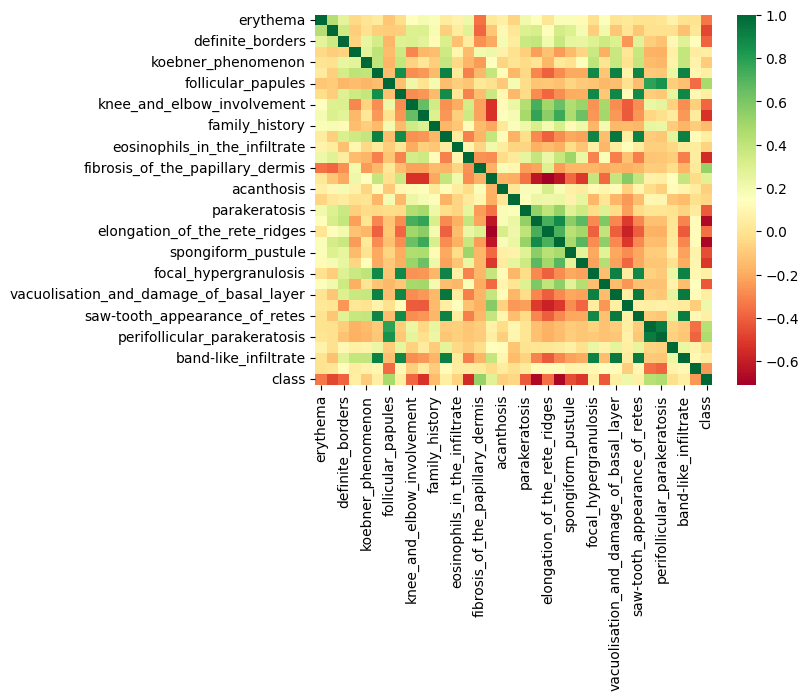

In [13]:
# check correlation via heatmap

plt.plot(figsize=(28,28))
sns.heatmap(df.corr(),cmap="RdYlGn")

In [17]:
#creating pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor=ColumnTransformer([('age',StandardScaler(),['Age'])],remainder='passthrough')

In [18]:
preprocessor

,transformers,"[('age', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [29]:
#Logistic Regression

X=df.drop(['class'],axis=1)
y=df['class']

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
pipeline_LR=Pipeline([('preprocessor',preprocessor),('model',LogisticRegression())])
pipeline_LR.fit(X_train,y_train)
y_pred_LR=pipeline_LR.predict(X_test)

In [22]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier
pipeline_DT=Pipeline([('preprocessor',preprocessor),('model',DecisionTreeClassifier())])
pipeline_DT.fit(X_train,y_train)
y_pred_DT=pipeline_DT.predict(X_test)

In [23]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
pipeline_RF=Pipeline([('preprocessor',preprocessor),('model',RandomForestClassifier())])
pipeline_RF.fit(X_train,y_train)
y_pred_RF=pipeline_RF.predict(X_test)

In [25]:
#SVM

from sklearn.svm import SVC
pipeline_SVM=Pipeline([('preprocessor',preprocessor),('model',SVC())])
pipeline_SVM.fit(X_train,y_train)
y_pred_SVM=pipeline_SVM.predict(X_test)

In [30]:
#model evaluation
#Model Comparison Report

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({ "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM"],"Accuracy":[accuracy_score(y_test, y_pred_LR),accuracy_score(y_test, y_pred_DT),accuracy_score(y_test, y_pred_RF),accuracy_score(y_test,y_pred_SVM)], "Precision": [precision_score(y_test, y_pred_LR, average="weighted"),
precision_score(y_test, y_pred_DT, average="weighted"),precision_score(y_test, y_pred_RF, average="weighted"),precision_score(y_test,y_pred_SVM,average="weighted")],"Recall": [recall_score(y_test, y_pred_LR, average="weighted"),recall_score(y_test, y_pred_DT, average="weighted"),recall_score(y_test, y_pred_RF, average="weighted"),
precision_score(y_test,y_pred_SVM,average="weighted") ],"F1 Score": [f1_score(y_test, y_pred_LR, average="weighted"),f1_score(y_test, y_pred_DT, average="weighted"),
f1_score(y_test, y_pred_RF, average="weighted"),f1_score(y_test,y_pred_SVM,average="weighted")]})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.972727,0.973147,0.972727,0.972670
1,Decision Tree,0.963636,0.963636,0.963636,0.963636
2,Random Forest,0.963636,0.965268,0.963636,0.963407
3,SVM,0.963636,0.965268,0.965268,0.963407


#Model Evaluation

The best performing model here was Logistic Regression, it's mainly because the data here is very linear. All the models overall performed great all across the board so you couldn't go wrong with any.

#Suggestions to dcotors

Based on the analysis, Logistic Regression can be used as an early screening and decision-support tool for identifying skin diseases, as it achieved the highest accuracy of 97.27% among the tested models. Doctors can use the patient’s clinical features and symptoms as inputs to help identify the most likely skin disorder at an early stage. Patients whose predicted results indicate a possible skin disease can then be prioritized for detailed dermatological examination and confirmation. The model should support, rather than replace, clinical diagnosis.



Skin Disease Classification – Data Analysis Report

1. Introduction

The objective of this project is to analyze clinical data related to skin disorders and develop a machine-learning model that can classify patients into different skin-disease categories. The analysis was performed using Python, Pandas, Seaborn, Matplotlib and Scikit-learn.

The final objective is to identify a suitable classification model that can assist doctors in the early identification and screening of skin diseases based on the clinical characteristics of a patient.

2. Dataset Description

The dataset contains 366 patient records and 35 columns.

* 34 columns represent clinical symptoms and characteristics.
* Age represents the patient’s age.
* Class is the target variable representing the skin-disease category.
* The clinical variables include characteristics such as erythema, scaling, itching, family history, follicular papules, oral mucosal involvement, hyperkeratosis, parakeratosis and other histopathological features.

The target variable contains multiple disease classes, making this a multiclass classification problem.

3. Data Exploration

The dataset was initially inspected using head(), info(), isnull().sum() and describe().

The data contained:

* 366 observations
* 35 columns
* 34 numerical columns
* 1 object column (Age) initially
* No major duplicate or irrelevant identifier column was present.

The Age column contained some values represented by ?, which were treated as missing values.

4. Data Cleaning

The ? values were first converted into NaN values:

df.replace('?', np.nan, inplace=True)

This allowed the missing values to be handled using standard preprocessing techniques.

The missing values were present in the Age column. Since age is a numerical variable and the dataset is relatively small, median imputation was used.

imputer = SimpleImputer(strategy='median')
df[['Age']] = imputer.fit_transform(df[['Age']])

Median imputation was selected because it is less affected by extreme values than mean imputation.

5. Exploratory Data Analysis

Descriptive statistics and a correlation matrix were used to understand the distribution and relationships between the variables.

A correlation heatmap was also created to identify relationships between clinical features and to check for highly correlated variables.

The analysis indicated that the clinical variables contain useful information for distinguishing between the different disease classes. No feature was removed solely based on correlation because the clinical variables may provide useful information to the classification models even when their individual correlations are not extremely high.

6. Data Preprocessing

The target variable, class, was separated from the independent variables.

X = df.drop(['class'], axis=1)
y = df['class']

The data was divided into training and testing sets using a 70:30 split with random_state=42.

The Age variable was standardized using StandardScaler:

StandardScaler()

The remaining clinical variables were passed through without scaling.

A ColumnTransformer and Pipeline were used so that preprocessing and model training could be performed together.

This approach makes the workflow more consistent and reduces the possibility of accidentally applying different preprocessing steps to the training and testing data.

7. Machine Learning Models

Four classification algorithms were tested:

Logistic Regression

Logistic Regression was used as the first classification model. Despite being a relatively simple algorithm, it performed extremely well on this dataset.

Decision Tree

A Decision Tree was tested because it can model non-linear relationships and is relatively easy to interpret.

Random Forest

Random Forest was used as an ensemble-based method consisting of multiple decision trees. It can generally provide better generalization than a single decision tree.

Support Vector Machine

SVM was also tested because it is effective for classification problems, particularly when the number of features is relatively high compared with the number of observations.

8. Model Evaluation

The models were evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score

The results showed that all four models performed strongly on the dataset.

The Logistic Regression model was the best-performing model, achieving approximately:

Metric	Logistic Regression
Accuracy	97.27%
Precision	97.31%
Recall	97.27%
F1 Score	97.27%

The Decision Tree, Random Forest and SVM models also achieved approximately 96%+ accuracy, showing that the dataset contains strong predictive patterns that can be learned by different classification algorithms.

9. Best Model

Based on the evaluation results, Logistic Regression was selected as the final model.

The main reason for selecting Logistic Regression is its combination of:

* Highest overall accuracy
* High precision
* High recall
* High F1 score
* Simpler structure compared with ensemble models
* Easier interpretation and deployment

The very similar performance of the different algorithms also suggests that the underlying clinical features provide strong separation between the disease classes.

10. Suggestions to Doctors

Based on the analysis and machine-learning results, the developed Logistic Regression model can be considered as an early screening and decision-support tool for skin-disease identification.

Doctors could use the patient’s clinical characteristics as inputs to obtain an initial prediction of the likely disease category. Patients identified as potentially having a particular skin disorder can then be prioritized for detailed dermatological examination.

The model could be particularly useful for:

* Early screening of patients.
* Supporting doctors when several diseases have similar clinical symptoms.
* Prioritizing patients who require further investigation.
* Reducing the time required for preliminary classification.
* Supporting clinical decision-making using patterns identified from historical patient data.

However, the model should not replace professional medical diagnosis. Predictions should be followed by appropriate clinical examination and other diagnostic procedures before treatment decisions are made.

11. Recommendations for Further Improvement

Although the model achieved very high performance, the dataset contains only 366 records. Therefore, testing the model on a larger and more diverse dataset would provide a better indication of how well it generalizes to new patients.

Future improvements could include:

1. Increasing the size of the dataset.
2. Testing the models using cross-validation.
3. Performing hyperparameter tuning.
4. Investigating feature importance to identify which clinical characteristics contribute most to each disease classification.
5. Examining the confusion matrix to determine which diseases are most frequently confused with one another.
6. Testing additional classification algorithms such as XGBoost or K-Nearest Neighbours.
7. Evaluating the model on an independent external dataset.

12. Conclusion

The analysis demonstrates that machine learning can effectively classify skin disorders using clinical and histopathological characteristics.

Four classification algorithms—Logistic Regression, Decision Tree, Random Forest and SVM—were tested, and all produced strong results. Logistic Regression was the best-performing model, achieving approximately 97.27% accuracy with a 97.27% F1 score.

The results indicate that the available clinical features contain sufficient information to distinguish between the different disease categories. Therefore, the developed model has potential as an early screening and clinical decision-support system, provided that its predictions are validated by qualified medical professionals.

For future development, a larger dataset, cross-validation, feature-importance analysis and independent validation would make the model more robust and suitable for practical application.